# Gold Metrics Review

This notebook reviews the Gold outputs generated for the hospital analytics project.

It is intended for:
- analytical validation
- storytelling for the portfolio
- quick inspection of aggregated outputs

This notebook does not generate the Gold layer.
The Gold datasets are produced by the pipeline and only reviewed here.

In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [3]:
project_root = Path.cwd().resolve().parents[0]
gold_dir = project_root / "data" / "gold"

daily_path = gold_dir / "daily_patient_flow.csv"
department_path = gold_dir / "department_referral_summary.csv"
demographic_path = gold_dir / "demographic_summary.csv"

daily_path, department_path, demographic_path

(WindowsPath('C:/Users/willi/OneDrive/Área de Trabalho/PhaifferTech/repos/data-engineering-portfolio/projects/01-hospital-analytics/data/gold/daily_patient_flow.csv'),
 WindowsPath('C:/Users/willi/OneDrive/Área de Trabalho/PhaifferTech/repos/data-engineering-portfolio/projects/01-hospital-analytics/data/gold/department_referral_summary.csv'),
 WindowsPath('C:/Users/willi/OneDrive/Área de Trabalho/PhaifferTech/repos/data-engineering-portfolio/projects/01-hospital-analytics/data/gold/demographic_summary.csv'))

## Gold datasets

The Gold layer currently produces three analytical outputs:

- `daily_patient_flow.csv`
- `department_referral_summary.csv`
- `demographic_summary.csv`

These outputs are intended to support future PostgreSQL serving, API exposure, and dashboard consumption.

In [4]:
df_daily = pd.read_csv(daily_path)
df_department = pd.read_csv(department_path)
df_demographic = pd.read_csv(demographic_path)

df_daily.shape, df_department.shape, df_demographic.shape

((579, 7), (8, 5), (83, 6))

## Dataset shapes

This section confirms the size of each Gold output and helps validate whether the aggregation grains look reasonable.

In [5]:
df_daily.head()

,admission_date,total_patient_events,average_patient_waittime,average_patient_satisfaction_score,admitted_patient_events,null_department_referral_events,null_satisfaction_score_events
0,2023-01-04,19,40.473684,3.8,9,11,14
1,2023-01-05,20,31.500000,5.5,10,11,18
2,2023-01-06,26,34.884615,4.8,12,15,21
3,2023-01-07,15,38.200000,2.0,8,13,13
4,2023-01-08,14,35.714286,8.0,9,12,12


In [6]:
df_department.head()

,department_referral,total_patient_events,average_patient_waittime,average_patient_satisfaction_score,share_of_total_events
0,NaN,5400,35.293148,4.953472,0.585938
1,General Practice,1840,34.912500,5.061630,0.199653
2,Orthopedics,995,34.982915,4.858621,0.107964
3,Physiotherapy,276,36.565217,4.987952,0.029948
4,Cardiology,248,35.354839,5.140845,0.026910


In [7]:
df_demographic.head()

,patient_gender,patient_race,patient_age_band,total_patient_events,average_patient_waittime,average_patient_satisfaction_score
0,Female,African American,0_17,223,36.730942,5.192308
1,Female,African American,18_35,184,34.315217,4.804348
2,Female,African American,36_50,185,35.351351,5.491228
3,Female,African American,51_65,149,35.006711,4.800000
4,Female,African American,66_plus,170,34.588235,4.807692


In [ ]:
## Daily patient flow

This output is aggregated at the daily level.

Expected grain:
- 1 row per admission date

Main value:
- supports time-series analysis
- helps identify operational variation over time
- useful for dashboard trend charts

In [8]:
df_daily.columns.tolist(), df_daily.info()

<class 'pandas.DataFrame'>
RangeIndex: 579 entries, 0 to 578
Data columns (total 7 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   admission_date                      579 non-null    str    
 1   total_patient_events                579 non-null    int64  
 2   average_patient_waittime            579 non-null    float64
 3   average_patient_satisfaction_score  570 non-null    float64
 4   admitted_patient_events             579 non-null    int64  
 5   null_department_referral_events     579 non-null    int64  
 6   null_satisfaction_score_events      579 non-null    int64  
dtypes: float64(2), int64(4), str(1)
memory usage: 37.4 KB


(['admission_date',
  'total_patient_events',
  'average_patient_waittime',
  'average_patient_satisfaction_score',
  'admitted_patient_events',
  'null_department_referral_events',
  'null_satisfaction_score_events'],
 None)

In [9]:
df_daily["admission_date"] = pd.to_datetime(df_daily["admission_date"], errors="coerce")
df_daily = df_daily.sort_values("admission_date")

df_daily.head()

,admission_date,total_patient_events,average_patient_waittime,average_patient_satisfaction_score,admitted_patient_events,null_department_referral_events,null_satisfaction_score_events
0,2023-01-04,19,40.473684,3.8,9,11,14
1,2023-01-05,20,31.500000,5.5,10,11,18
2,2023-01-06,26,34.884615,4.8,12,15,21
3,2023-01-07,15,38.200000,2.0,8,13,13
4,2023-01-08,14,35.714286,8.0,9,12,12


In [10]:
df_daily.describe(include="all").T

,count,mean,min,25%,50%,75%,max,std
admission_date,579,2024-01-12 21:55:38.860103,2023-01-04 00:00:00,2023-08-11 12:00:00,2024-01-17 00:00:00,2024-06-19 12:00:00,2024-12-10 00:00:00,NaN
total_patient_events,579.0,15.917098,7.0,13.0,16.0,18.0,30.0,3.726836
average_patient_waittime,579.0,35.221006,24.5,32.575368,35.05,37.815341,45.470588,3.873111
average_patient_satisfaction_score,570.0,5.045583,0.0,4.0,5.0,6.0,10.0,1.689453
admitted_patient_events,579.0,7.965458,1.0,6.0,8.0,10.0,17.0,2.66637
null_department_referral_events,579.0,9.326425,2.0,7.0,9.0,11.0,23.0,2.996915
null_satisfaction_score_events,579.0,11.569948,4.0,9.0,11.0,14.0,26.0,3.372471


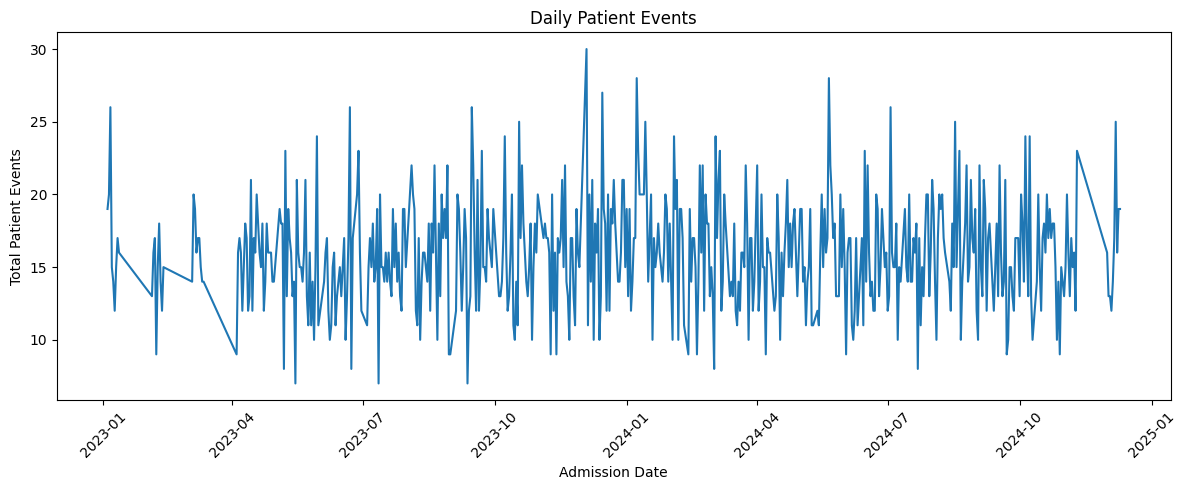

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(df_daily["admission_date"], df_daily["total_patient_events"])
plt.title("Daily Patient Events")
plt.xlabel("Admission Date")
plt.ylabel("Total Patient Events")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

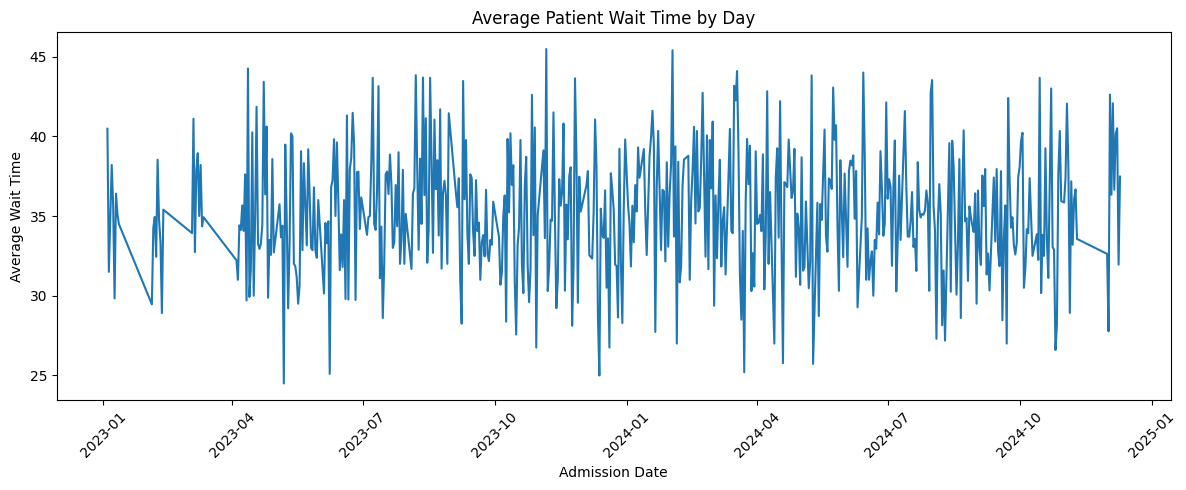

In [12]:
plt.figure(figsize=(12, 5))
plt.plot(df_daily["admission_date"], df_daily["average_patient_waittime"])
plt.title("Average Patient Wait Time by Day")
plt.xlabel("Admission Date")
plt.ylabel("Average Wait Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Department referral summary

This output is aggregated by department referral.

Expected grain:
- 1 row per department referral category

Main value:
- supports comparison across referral groups
- helps identify concentration of patient events
- useful for ranking and categorical dashboard charts

In [13]:
df_department.columns.tolist(), df_department.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   department_referral                 7 non-null      str    
 1   total_patient_events                8 non-null      int64  
 2   average_patient_waittime            8 non-null      float64
 3   average_patient_satisfaction_score  8 non-null      float64
 4   share_of_total_events               8 non-null      float64
dtypes: float64(3), int64(1), str(1)
memory usage: 533.0 bytes


(['department_referral',
  'total_patient_events',
  'average_patient_waittime',
  'average_patient_satisfaction_score',
  'share_of_total_events'],
 None)

In [14]:
df_department = df_department.sort_values("total_patient_events", ascending=False)
df_department

,department_referral,total_patient_events,average_patient_waittime,average_patient_satisfaction_score,share_of_total_events
0,NaN,5400,35.293148,4.953472,0.585938
1,General Practice,1840,34.912500,5.061630,0.199653
2,Orthopedics,995,34.982915,4.858621,0.107964
3,Physiotherapy,276,36.565217,4.987952,0.029948
4,Cardiology,248,35.354839,5.140845,0.026910
5,Neurology,193,36.803109,5.283019,0.020942
6,Gastroenterology,178,35.831461,5.796296,0.019314
7,Renal,86,34.697674,4.565217,0.009332


In [22]:
df_department_plot = df_department.copy()

df_department_plot["department_referral_label"] = (
    df_department_plot["department_referral"]
    .fillna("Unknown / Missing")
    .astype(str)
)

df_department_plot[[
    "department_referral",
    "department_referral_label",
    "total_patient_events",
    "share_of_total_events"
]]

,department_referral,department_referral_label,total_patient_events,share_of_total_events
0,NaN,Unknown / Missing,5400,0.585938
1,General Practice,General Practice,1840,0.199653
2,Orthopedics,Orthopedics,995,0.107964
3,Physiotherapy,Physiotherapy,276,0.029948
4,Cardiology,Cardiology,248,0.026910
5,Neurology,Neurology,193,0.020942
6,Gastroenterology,Gastroenterology,178,0.019314
7,Renal,Renal,86,0.009332


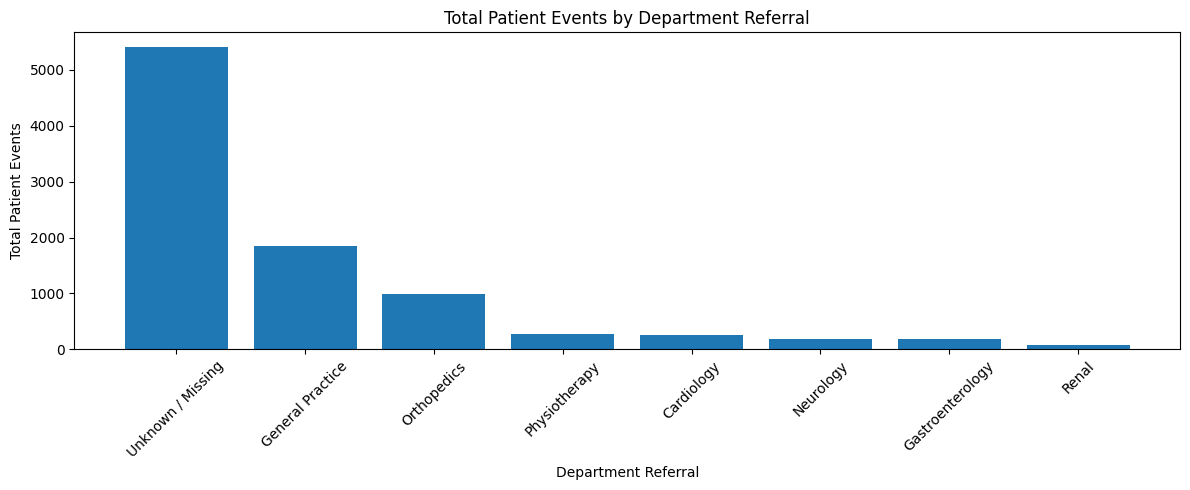

In [24]:
plt.figure(figsize=(12, 5))
plt.bar(
    df_department_plot["department_referral_label"],
    df_department_plot["total_patient_events"]
)
plt.title("Total Patient Events by Department Referral")
plt.xlabel("Department Referral")
plt.ylabel("Total Patient Events")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

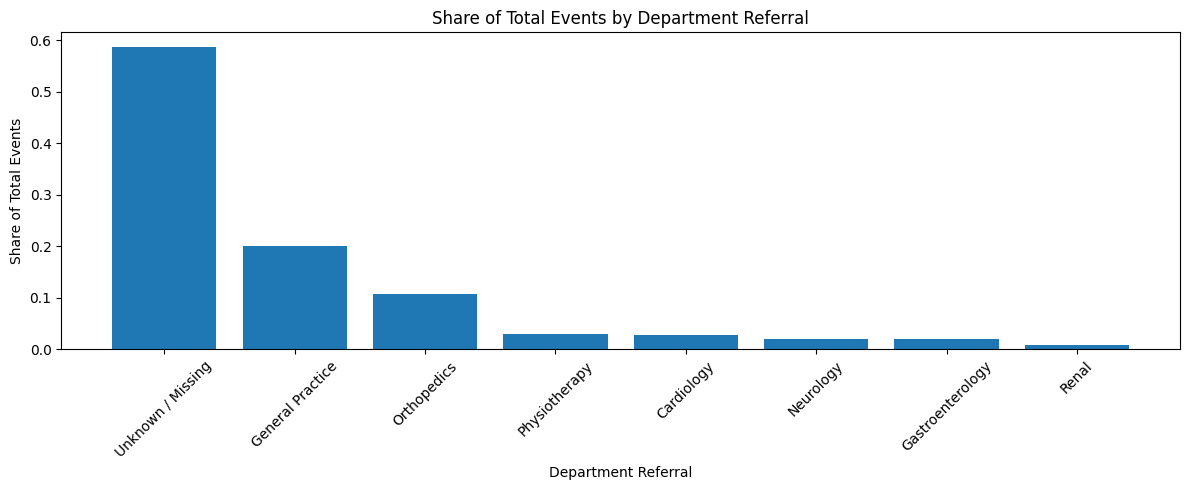

In [25]:
plt.figure(figsize=(12, 5))
plt.bar(
    df_department_plot["department_referral_label"],
    df_department_plot["share_of_total_events"]
)
plt.title("Share of Total Events by Department Referral")
plt.xlabel("Department Referral")
plt.ylabel("Share of Total Events")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Demographic summary

This output is aggregated by demographic grouping.

Expected grain:
- 1 row per demographic group

Main value:
- supports segmentation analysis
- allows comparison across patient profiles
- can be used for dashboard filters and grouped summaries

In [17]:
df_demographic.columns.tolist(), df_demographic.info()

<class 'pandas.DataFrame'>
RangeIndex: 83 entries, 0 to 82
Data columns (total 6 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   patient_gender                      83 non-null     str    
 1   patient_race                        83 non-null     str    
 2   patient_age_band                    83 non-null     str    
 3   total_patient_events                83 non-null     int64  
 4   average_patient_waittime            83 non-null     float64
 5   average_patient_satisfaction_score  74 non-null     float64
dtypes: float64(2), int64(1), str(3)
memory usage: 6.1 KB


(['patient_gender',
  'patient_race',
  'patient_age_band',
  'total_patient_events',
  'average_patient_waittime',
  'average_patient_satisfaction_score'],
 None)

In [18]:
df_demographic = df_demographic.sort_values("total_patient_events", ascending=False)
df_demographic.head(15)

,patient_gender,patient_race,patient_age_band,total_patient_events,average_patient_waittime,average_patient_satisfaction_score
79,Male,White,18_35,296,36.320946,4.440860
31,Female,White,18_35,291,35.841924,5.310345
78,Male,White,0_17,274,36.197080,5.152941
30,Female,White,0_17,263,35.110266,4.671875
33,Female,White,51_65,251,35.450199,4.656716
80,Male,White,36_50,250,34.852000,5.472222
32,Female,White,36_50,244,34.254098,5.166667
49,Male,African American,18_35,243,35.604938,5.145161
81,Male,White,51_65,241,33.477178,5.072464
82,Male,White,66_plus,240,34.887500,4.640625


In [19]:
top_demographic = df_demographic.head(10).copy()
top_demographic["demographic_label"] = (
    top_demographic["patient_gender"].astype(str)
    + " | "
    + top_demographic["patient_race"].astype(str)
    + " | "
    + top_demographic["patient_age_band"].astype(str)
)

top_demographic[["demographic_label", "total_patient_events"]]

,demographic_label,total_patient_events
79,Male | White | 18_35,296
31,Female | White | 18_35,291
78,Male | White | 0_17,274
30,Female | White | 0_17,263
33,Female | White | 51_65,251
80,Male | White | 36_50,250
32,Female | White | 36_50,244
49,Male | African American | 18_35,243
81,Male | White | 51_65,241
82,Male | White | 66_plus,240


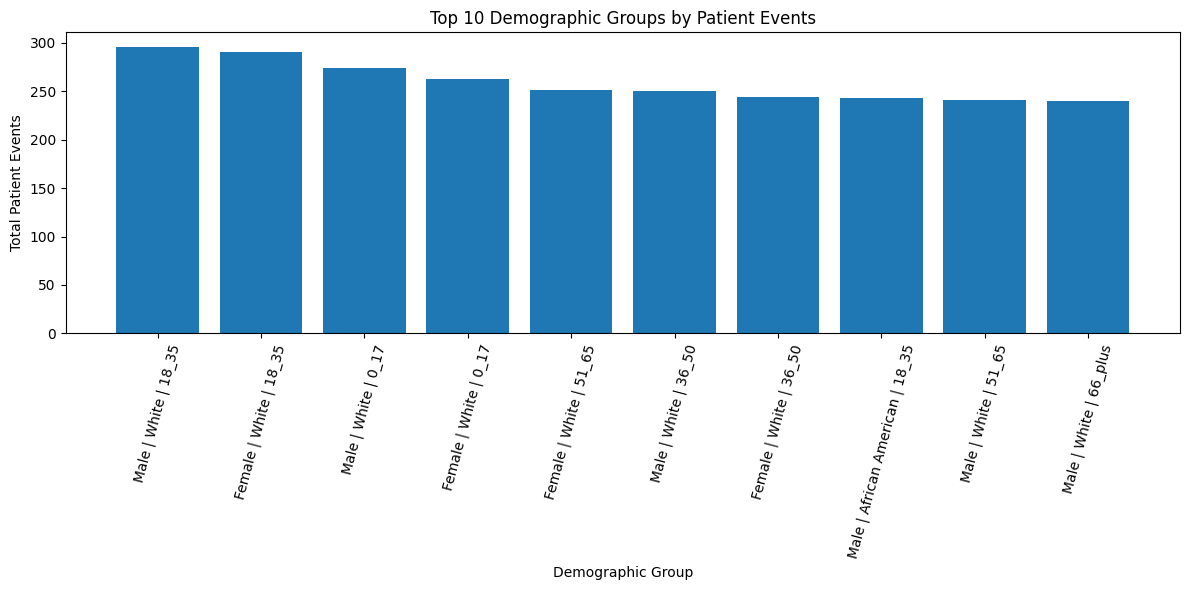

In [20]:
plt.figure(figsize=(12, 6))
plt.bar(top_demographic["demographic_label"], top_demographic["total_patient_events"])
plt.title("Top 10 Demographic Groups by Patient Events")
plt.xlabel("Demographic Group")
plt.ylabel("Total Patient Events")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

## Portfolio interpretation

At this point, the project already demonstrates:

- raw ingestion from Kaggle
- Bronze profiling and metadata
- Silver structural standardization
- Gold analytical outputs ready for serving

These Gold datasets are strong candidates for:
- PostgreSQL loading
- serving views
- Flask API endpoints
- dashboard visualizations

In [21]:
kpis = {
    "daily_points": len(df_daily),
    "department_groups": len(df_department),
    "demographic_groups": len(df_demographic),
    "total_events_from_daily": int(df_daily["total_patient_events"].sum()),
    "overall_average_waittime": float(df_daily["average_patient_waittime"].mean()),
    "overall_average_satisfaction": float(df_daily["average_patient_satisfaction_score"].mean()),
}

pd.Series(kpis)

daily_points                     579.000000
department_groups                  8.000000
demographic_groups                83.000000
total_events_from_daily         9216.000000
overall_average_waittime          35.221006
overall_average_satisfaction       5.045583
dtype: float64

## Next step

The next architectural step is to load Gold outputs into PostgreSQL and expose them through a serving layer for future API and dashboard consumption.